# Bibliotecas utilizadas


In [ ]:
import os
import cv2
from pathlib import Path
import time as t
import numpy as np
import matplotlib.pyplot as plt

'''tqdm é uma biblioteca que envolve essa lista para mostrar uma barra de progresso
 animada no terminal, exibindo o texto "Processando" e indicando a unidade como "img" (imagens). '''
from tqdm import tqdm 


## Processamento de Lote (Batch)

In [ ]:
# Classe responsavel por as conversoe
# Denominada de Preprocessamento de Lote
class Processor:
    def __init__(self, blur_kernel=(5, 5), canny_threshold1=50, canny_threshold2=150):
        self.blur_kernel = blur_kernel  # borracha
        self.canny_threshold1 = canny_threshold1  # limite minimo para detectar bordas 
        self.canny_threshold2 = canny_threshold2  # limite maximo para detectar bordas 

        # Extensoes aceitas
        self.extensions = ('.jpeg', '.jpg', '.png', '.bmp')

    def leitor(self, path):
        # lendo a imagem da pasta
        img = cv2.imread(path)

        # Condição se achou ou não
        if img is None:
            print("Não foi encontrado a imagem!")
            return None
        
        else:
            # fazendo exceções caso de erro continuo
            try:
                return img
            
            except Exception as e: # Exceção generalizada
                print("Ainda não abriu!!!")
                return None


    def cinza(self, img):
        # retorna a imagem em cinza
        return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    def apply_blur(self, img):
        # Aplicando um desfoque na img reduzindo os ruidos e usa a borracha suave para limpar antes de analisar img.
        return cv2.GaussianBlur(img, self.blur_kernel, 0)

    def threshold(self, img):
        # vamos coverter em preto(0) e branco puro(255)
        # THRESH_BINARY diz para transformar em preto e branco
        # THRESH_OTSU avisa ao OpenCV para calcular o ponto de corte ideal automaticamente.
        _, binario = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        return binario
    

    def morpho(self, img):
        #
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))  # Elemento estruturante 3x3
        opened = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)     # Remove ruídos pequenos
        closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel) # Fecha buracos pequenos
        return closed


    def detectar_edges(self, img):
        # detector de bordas e ranhuras na peça da imagem , com algoritmo Canny que faz bem isso.
        # e ele destacar tais detalhes
        edges = cv2.Canny(img, self.canny_threshold1, self.canny_threshold2)
        return edges
    

    def resize_img(self, img, size=(256, 256)):
        # vamos redimensiona a imagem para tamanho 256 x 256
        # Isso é importante para que todas as imagens fiquem iguais antes de treinar um modelo de IA.
        return cv2.resize(img, size)

    def preprocess_img(self, input_path, output_path):
        # Lê a imagem
        img = self.leitor(input_path)
        
        if img is None:
            return False

        # Converte para escala de cinza
        gray = self.cinza(img)

        # Reduz ruído (Blur)
        blurred = self.apply_blur(gray)

        # Aplica limiarização (Otsu)
        binary = self.threshold(blurred)

        # Limpa a imagem com morfologia
        morph = self.morpho(binary)

        # Detecta as bordas (Canny)
        edges = self.detectar_edges(morph)

        # Redimensiona para 256x256
        final = self.resize_img(edges, size=(256, 256))

        # Agora cria o painel com todas as etapas processadas em unica imagem
        # Juntar todas as etapas em uma única imagem
        # Redimensiona todas para o mesmo tamanho
        h, w = 256, 256


        original = cv2.resize(img, (w, h))
        gray = cv2.cvtColor(cv2.resize(gray, (w, h)), cv2.COLOR_GRAY2BGR)
        blurred = cv2.cvtColor(cv2.resize(blurred, (w, h)), cv2.COLOR_GRAY2BGR)
        binary = cv2.cvtColor(cv2.resize(binary, (w, h)), cv2.COLOR_GRAY2BGR)
        morph = cv2.cvtColor(cv2.resize(morph, (w, h)), cv2.COLOR_GRAY2BGR)
        edges = cv2.cvtColor(cv2.resize(edges, (w, h)), cv2.COLOR_GRAY2BGR)
        final = cv2.cvtColor(cv2.resize(final, (w, h)), cv2.COLOR_GRAY2BGR)

        # Junta na horizontal (uma do lado da outra)
        painel = np.hstack([original, gray, blurred, binary, morph, edges, final])

        # Salva o painel
        cv2.imwrite(output_path, painel)
        return True
    

    def process_wrapper(self, filename, input_dir, output_dir):
        try:
            # cria o caminho completo de entrada
            in_path = os.path.join(input_dir, filename)

            # separa o nome do arquivo por sua extensão e pega apenas o nome da imagem
            base_name = os.path.splitext(filename)[0]  # '0' para seleciona o primeiro elemento tirando o nome da extensoes. Ex: foto.jpeg > foto. 

            # definir o caminho da saida quer as imagens terão
            out_path = os.path.join(output_dir, f"{base_name}.png")

            return self.preprocess_img(in_path, out_path)

        # tratamento de erro
        except Exception as e:
            print(f"Erro ao processar {filename}: {e}")
            return False



    def process_batch(self, input_dir, output_dir, limit=None):
        # Processa várias imagens de uma vez (em lote). 
        # começa o tempo   
        start_time = t.perf_counter()

        # Cria a pasta de saída se não existir
        Path(output_dir).mkdir(parents=True, exist_ok=True)

        # Lista só os arquivos que são imagens
        files = [f for f in os.listdir(input_dir) if f.lower().endswith(self.extensions)]
        if limit:
            '''Se a variável limit existir (ou tiver um valor maior que zero ou verdadeiro), corte a 
                         lista files para que ela tenha, no máximo, o número de itens definido por limit '''
            files = files[:limit]


        # caso nao seja validada a imagem buscada
        if not files:
            print(f"Nenhuma imagem válida encontrada em: {input_dir}")
            return


        # retornar o número de itens ou o tamanho dentro files
        print(f"Iniciando processamento de {len(files)} imagens...")

        success = 0

        # fazendo a contagem de arquivos processados com sucesso enquanto exibe uma barra de progresso para o usuário na saida. 
        # Laço a seguir vai passar por cada arquivo da sua lista (files).
        for filename in tqdm(files, desc="Processando", unit="img"):
            # Envia o arquivo(filename) atual, junto com as pastas 
            if self.process_wrapper(filename, input_dir, output_dir):
                success += 1

        # termina o tempo
        end_time = t.perf_counter()
        print(f"\n{success} imagens processadas com sucesso em {end_time - start_time:.2f} segundos.")

In [5]:
print("Pasta acessadas com sucesso!")

# Sobe a partir do notebook até achar a pasta raiz do projeto
NOTEBOOK_DIR = Path.cwd().parent
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "projeto-mini-02" else NOTEBOOK_DIR


Pasta acessadas com sucesso!


## Aqui o pulo do gato é fazer ao mesmo tempo o preenchimento com as conversões das imagens únicas em suas respectivas pastras de processed

In [6]:
# usando a classe
processar = Processor()

PROJECT_ROOT = Path.cwd().parent

input_dir = PROJECT_ROOT / "raw_images" / "def_front"
output_dir = PROJECT_ROOT / "processed_images" / "def_front_processed"

processar.process_batch(
    input_dir=input_dir,
    output_dir=output_dir
)

input_dir2 = PROJECT_ROOT / "raw_images" / "ok_front"
output_dir2 = PROJECT_ROOT / "processed_images" / "ok_front_processed"

processar.process_batch(
    input_dir=input_dir2,
    output_dir=output_dir2
)

Iniciando processamento de 781 imagens...


Processando: 100%|██████████| 781/781 [00:06<00:00, 115.62img/s]



781 imagens processadas com sucesso em 6.77 segundos.
Iniciando processamento de 519 imagens...


Processando: 100%|██████████| 519/519 [00:04<00:00, 117.18img/s]


519 imagens processadas com sucesso em 4.43 segundos.


## Testando 

In [8]:
path = '/home/delmar/Downloads/mine_projeto_bloco_1-main/Delmar_AI/Demonstration/projeto-mini-02/raw_images/def_front/cast_def_0_0.jpeg'

img = processar.leitor(path)

print("\nImagem carregada?")
print(img is not None)

if img is not None:
    print("Tamanho:", img.shape)


Imagem carregada?
True
Tamanho: (512, 512, 3)


In [9]:
# Lê a imagem ORIGINAL
img = processar.leitor(path)

# Cada processamento da classe sendo usado a partir da imagem ORIGINAL

gray = processar.cinza(img)

blurred = processar.apply_blur(img)

binary = processar.threshold(
    processar.cinza(img)
)

morph = processar.morpho(
    processar.threshold(
        processar.cinza(img)
    )
)

edges = processar.detectar_edges(
    processar.cinza(img)
)


# Exibe cada resultado
cv2.imshow("Original", img)
cv2.imshow("Cinza", gray)
cv2.imshow("Blur", blurred)
cv2.imshow("Threshold", binary)
cv2.imshow("Morpho", morph)
cv2.imshow("Edges", edges)


# Aguarda uma tecla
cv2.waitKey(0)

cv2.destroyAllWindows()

QFontDatabase: Cannot find font directory /home/delmar/Downloads/mine_projeto_bloco_1-main/Delmar_AI/Demonstration/projeto-mini-02/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/delmar/Downloads/mine_projeto_bloco_1-main/Delmar_AI/Demonstration/projeto-mini-02/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/delmar/Downloads/mine_projeto_bloco_1-main/Delmar_AI/Demonstration/projeto-mini-02/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/delmar/Downloads/mine_projeto_bloco_1-ma

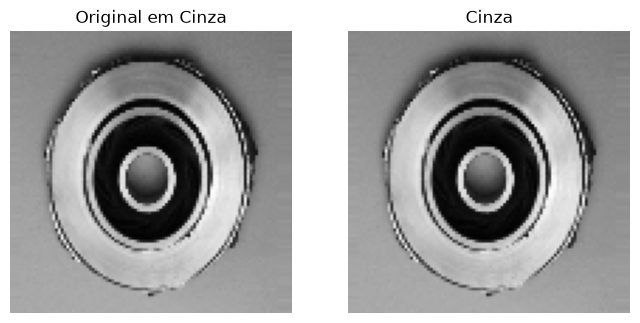

Original (pixel 50,50): [111 111 111]
Gray (pixel 50,50): 111


In [10]:
path = '/home/delmar/Downloads/mine_projeto_bloco_1-main/Delmar_AI/Demonstration/projeto-mini-02/raw_images/def_front/cast_def_0_0.jpeg'


# Lendo a imagem da pasta
img = cv2.imread(path)

if img is not None:

    # tamanho de saida 
    img_resized = cv2.resize(img, (100, 100))

    gray = processar.cinza(img_resized)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY), cmap="gray")
    axes[0].set_title("Original em Cinza")
    axes[0].axis("off")

    axes[1].imshow(gray, cmap="gray")
    axes[1].set_title("Cinza")
    axes[1].axis("off")

    plt.show()

    print("Original (pixel 50,50):", img_resized[50, 50])
    print("Gray (pixel 50,50):", gray[50, 50])


else:
    print("ERRO: A imagem ainda não foi encontrada.")
    print("Caminho usado:", path)